In [1]:
import pathlib

import numpy as np
import xarray as xr
import bordado as bd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import simpeg
from simpeg.electromagnetics import natural_source
import discretize

import inversion_ideas as ii

In [2]:
assert "dev" in simpeg.__version__
print(simpeg.__version__)

0.25.2.dev198+g3b722ceb9


In [3]:
air_conductivity = 1e-8
background_conductivity = 1e-3

In [4]:
frequencies = np.logspace(1, 3, 7)

In [5]:
x, z = bd.grid_coordinates(
    (-3e3, 3e3), 
    spacing=200.0, 
    non_dimensional_coords=0.0,
)
receivers_locations = np.vstack([x, z]).T

In [6]:
def get_power_of_two_cells(n):
    exp = np.ceil(np.log2(n))
    return 2 ** int(exp)
    
min_cell_size = 5.0
region_size = 40000.0

n_cells = get_power_of_two_cells(region_size / min_cell_size)
n_cells

hx = [(min_cell_size, n_cells)]
h = [hx, hx]
mesh = discretize.TreeMesh([hx, hx], origin="CC", diagonal_balance=True)

topo_x, topo_z = bd.grid_coordinates((-4e3, 4e3), shape=(501,), non_dimensional_coords=0)
mesh.refine_surface(
    np.vstack((topo_x, topo_z)).T,
    padding_cells_by_level=[0, 0, 0, 4, 4, 4, 8],
    finalize=False,
)
    

mesh.refine_points(
    receivers_locations,
    padding_cells_by_level=[6],
    finalize=False,
)

# mesh.refine_box(*block_corners, levels=-3, finalize=False)

mesh.finalize()
mesh

QuadTreeMesh,0.02% filled
Level,Number of cells
3,42
4,50
5,74
6,118
7,584
8,438
9,818
10,1356
11,1556


In [7]:
_, cell_centers_z = mesh.cell_centers.T
active_cells = cell_centers_z <= 0
n_active = np.sum(active_cells)
print(n_active)

8912


In [8]:
conductivity_map = simpeg.maps.InjectActiveCells(
    mesh, active_cells, air_conductivity
)
plotting_map = simpeg.maps.InjectActiveCells(
    mesh, active_cells, np.nan
)
log_conductivity_map = conductivity_map * simpeg.maps.ExpMap(nP=n_active)
log_plotting_map = plotting_map * simpeg.maps.ExpMap(nP=n_active)

## Build SimPEG simulation

In [9]:
# Define 1D mesh using vertical discretization of the 2D/3D mesh
hz_1d = mesh.h[-1]
mesh_1d = discretize.TensorMesh([hz_1d], origin=np.array([mesh.origin[-1]]))

# Assign conductivity values
sigma_1d = air_conductivity * np.ones(mesh_1d.n_cells)
sigma_1d[mesh_1d.cell_centers < 0.0] = background_conductivity

In [10]:
def build_mt_survey(stations, frequencies, components=("real", "imag"), orientations=("xy", "yx")):
    """
    Build one source per frequency.
    
    Each source will have receivers for the real and imaginary components of the
    Z_{xy} and Z_{yx} impedance components.
    """
    sources = []
    for frequency in frequencies:
        receivers = [
            natural_source.receivers.Impedance(
                locations_e=stations, 
                locations_h=stations,
                orientation=orientation,
                component=component,
            )
            for component in components
            for orientation in orientations # the last one changes faster
        ]
        sources.append(
            natural_source.sources.FictitiousSource(
                receiver_list=receivers, frequency=frequency
            )
        )

    survey = natural_source.Survey(sources)
    return survey

In [11]:
survey = build_mt_survey(receivers_locations, frequencies, orientations=("xy",))
survey

In [12]:
simulation_simpeg = natural_source.simulation.Simulation2DElectricFieldFictitious(
    mesh,
    survey=survey,
    sigma_background=sigma_1d,
    sigmaMap=log_conductivity_map,
    solver=simpeg.utils.get_default_solver(),
)

## Wrap simulation

In [13]:
from scipy.sparse.linalg import LinearOperator
from inversion_ideas.decorators import cache_on_model

class SimulationMT(ii.base.Simulation):

    def __init__(self, simulation, store_jacobian=False, cache=True):
        self.simulation = simulation
        self.cache = cache
        self.store_jacobian = store_jacobian
        
    @property
    def n_data(self):
        return self.simulation.survey.nD

    @property
    def n_params(self):
        n_params = self.simulation.sigmaMap.nP
        return n_params

    @cache_on_model
    def __call__(self, model):
        return self.simulation.dpred(model)

    @cache_on_model
    def jacobian(self, model):
        if not self.store_jacobian:
            operator = LinearOperator(
                shape=(self.n_data, self.n_params),
                dtype=np.float64,
                matvec=lambda v: self.simulation.Jvec(model, v),
                rmatvec=lambda v: self.simulation.Jtvec(model, v),
            )
            return operator
        return self.simulation.getJ(model)

In [14]:
simulation_mt = SimulationMT(simulation_simpeg)

In [15]:
initial_model = np.log(background_conductivity) * np.ones(n_active)
initial_model[0]

np.float64(-6.907755278982137)

In [16]:
logger = ii.utils.get_logger()
logger.setLevel("DEBUG")

In [17]:
dpred = simulation_mt(initial_model)

Computing fields for model 140714003286320


[DEBUG] 2026-08-13 15:49:39,451 | Computed new result '[-0.19869179 -0.19869179 -0.19869179 ... -1.99676265 -1.99676265 -1.99676265]' after calling '<function SimulationMT.__call__ at 0x7ffa882cb690>' with model with hash '2ab2418e591a29b7eb8cfa40f86001cfde93cbfde631837c624e077c25b56183'. Cached the result into the object.


In [18]:
jac = simulation_mt.jacobian(initial_model)

[DEBUG] 2026-08-13 15:49:40,484 | Computed new result '<434x8912 _CustomLinearOperator with dtype=float64>' after calling '<function SimulationMT.jacobian at 0x7ffa882cb7f0>' with model with hash '2ab2418e591a29b7eb8cfa40f86001cfde93cbfde631837c624e077c25b56183'. Cached the result into the object.


In [20]:
result = jac @ initial_model

Computing fields for model 140714003286320


## Build inversion

In [16]:
def ravel_dataset(dataset):
    zxy_real, zxy_imag = dataset.z_xy_real.values, dataset.z_xy_imag.values
    zxy = np.concatenate((zxy_real[:, None, :], zxy_imag[:, None, :]), axis=1)
    return zxy.ravel()

In [17]:
data = ravel_dataset(dataset)

uncertainty = 0.01
uncertainties = np.full(data.size, fill_value=uncertainty)

In [18]:
data_misfit = ii.DataMisfit(data, uncertainties, simulation_mt)
data_misfit

φd(m)

In [19]:
model_norm = (
    1e-6 * ii.Smallness(
        mesh, 
        active_cells=active_cells,
        reference_model=initial_model,
    )
    + ii.Flatness(
        mesh,
        active_cells=active_cells,
        direction="x",
    )
    + ii.Flatness(
        mesh,
        active_cells=active_cells,
        direction="y",
    ).set_name("z")
).flatten()
model_norm

1.e-06 φs(m) + φx(m) + φz(m)

In [20]:
regularization = 700.0 * model_norm
phi = data_misfit + regularization
phi

φd(m) + 700. [1.e-06 φs(m) + φx(m) + φz(m)]

In [21]:
minimizer = ii.minimize.GaussNewtonConjugateGradient(
    maxiter=3,
    cg_kwargs={"rtol": 1e-1},
)

chi_target = ii.conditions.ChiTarget(data_misfit)
cooler = ii.directives.MultiplierCooler(regularization, cooling_factor=2.0)

preconditioner = ii.JacobiPreconditioner(phi)

inversion = ii.Inversion(
    phi,
    initial_model,
    minimizer,
    directives=[cooler],
    stopping_criterion=chi_target,
    minimizer_kwargs={"preconditioner": preconditioner},
)

In [22]:
inverted_model = inversion.run()

Output()

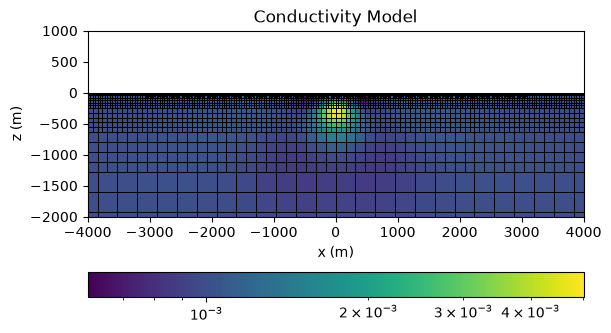

In [23]:
from matplotlib.colors import LogNorm

values = log_plotting_map * inverted_model

fig, ax = plt.subplots()
norm = LogNorm(vmin=np.nanmin(values), vmax=np.nanmax(values))

tmp, = mesh.plot_image(
    log_plotting_map * inverted_model,
    ax=ax,
    grid=True,
    pcolor_opts={"norm": norm, "cmap": "viridis"},
    grid_opts={"color":"k", "linewidth": 0.5}
)
ax.set_xlim(-4e3, 4e3)
ax.set_ylim(-2e3, 1e3)
ax.set_title("Conductivity Model")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_aspect("equal")
plt.colorbar(tmp, ax=ax, orientation="horizontal")
plt.show()

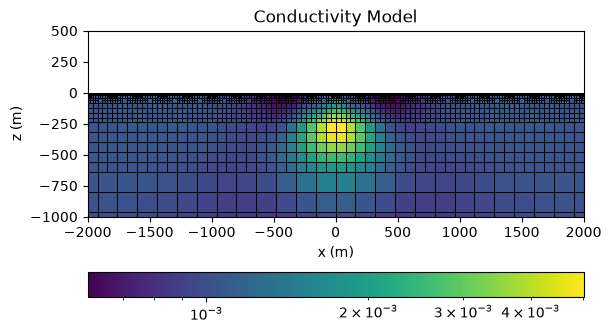

In [24]:
from matplotlib.colors import LogNorm


values = log_plotting_map * inverted_model

fig, ax = plt.subplots()
norm = LogNorm(vmin=np.nanmin(values), vmax=np.nanmax(values))

tmp, = mesh.plot_image(
    log_plotting_map * inverted_model,
    ax=ax,
    grid=True,
    pcolor_opts={"norm": norm, "cmap": "viridis"},
    grid_opts={"color":"k", "linewidth": 0.5}
)
ax.set_xlim(-2e3, 2e3)
ax.set_ylim(-1e3, 500)
ax.set_title("Conductivity Model")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_aspect("equal")
plt.colorbar(tmp, ax=ax, orientation="horizontal")
plt.show()

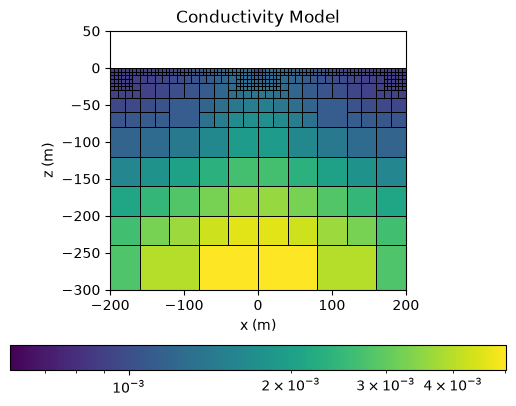

In [25]:
from matplotlib.colors import LogNorm


values = log_plotting_map * inverted_model

fig, ax = plt.subplots()
norm = LogNorm(vmin=np.nanmin(values), vmax=np.nanmax(values))

tmp, = mesh.plot_image(
    log_plotting_map * inverted_model,
    ax=ax,
    grid=True,
    pcolor_opts={"norm": norm, "cmap": "viridis"},
    grid_opts={"color":"k", "linewidth": 0.5}
)
ax.set_xlim(-200, 200)
ax.set_ylim(-300, 50)
ax.set_title("Conductivity Model")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_aspect("equal")
plt.colorbar(tmp, ax=ax, orientation="horizontal")
plt.show()

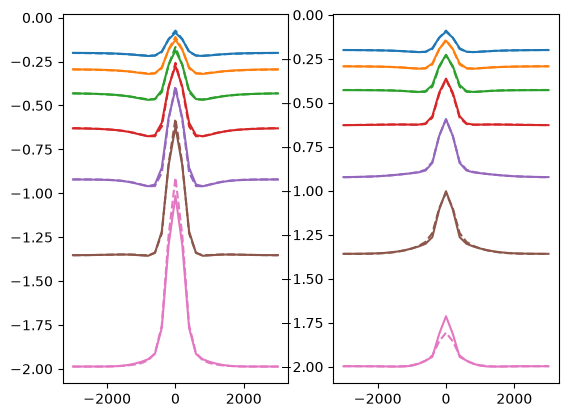

In [26]:
shape = (len(frequencies), 2, receivers_locations.shape[0])

true_data = data_misfit.data.reshape(shape)
zxy_real_true, zxy_imag_true = true_data[:, 0, :], true_data[:, 1, :]

data = simulation_mt(inverted_model).reshape(shape)
zxy_real, zxy_imag = data[:, 0, :], data[:, 1, :]

fig, (ax1, ax2) = plt.subplots(ncols=2)

for i, freq in enumerate(frequencies):
    ax1.plot(receivers_locations[:, 0], zxy_real_true[i, :], linestyle="--", color=f"C{i}")
    ax1.plot(receivers_locations[:, 0], zxy_real[i, :], color=f"C{i}")
    
    ax2.plot(receivers_locations[:, 0], zxy_imag_true[i, :], linestyle="--", color=f"C{i}")
    ax2.plot(receivers_locations[:, 0], zxy_imag[i, :], color=f"C{i}")
    
# plt.legend(loc="lower right")
plt.show()

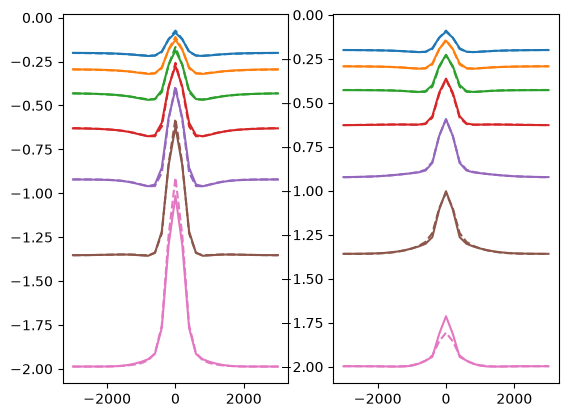

In [27]:
shape = (len(frequencies), 2, receivers_locations.shape[0])

true_data = data_misfit.data.reshape(shape)
zxy_real_true, zxy_imag_true = true_data[:, 0, :], true_data[:, 1, :]

data = simulation_simpeg.dpred(inverted_model).reshape(shape)
zxy_real, zxy_imag = data[:, 0, :], data[:, 1, :]

fig, (ax1, ax2) = plt.subplots(ncols=2)

for i, freq in enumerate(frequencies):
    ax1.plot(receivers_locations[:, 0], zxy_real_true[i, :], linestyle="--", color=f"C{i}")
    ax1.plot(receivers_locations[:, 0], zxy_real[i, :], color=f"C{i}")
    
    ax2.plot(receivers_locations[:, 0], zxy_imag_true[i, :], linestyle="--", color=f"C{i}")
    ax2.plot(receivers_locations[:, 0], zxy_imag[i, :], color=f"C{i}")
    
# plt.legend(loc="lower right")
plt.show()

In [28]:
np.nanmin(values)

np.float64(0.0006020252644475696)

In [29]:
np.nanmax(values)

np.float64(0.005018515765268885)

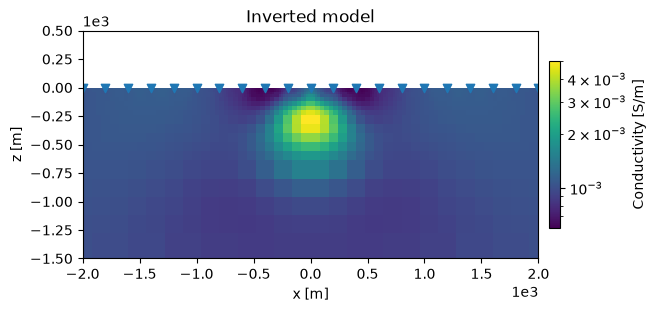

In [30]:
figsize_cm = (18, 11)
figsize_inch = tuple(s * 0.3937008 for s in figsize_cm)

values = log_plotting_map * inverted_model

fig, ax = plt.subplots(figsize=figsize_inch)
norm = LogNorm(vmin=np.nanmin(values), vmax=np.nanmax(values))

tmp, = mesh.plot_image(
    values,
    ax=ax,
    grid=False,
    pcolor_opts={"norm": norm, "cmap": "viridis", "rasterized": True},
    # grid_opts={"color":"k", "linewidth": 0.5}
)

x, z = receivers_locations.T
ax.scatter(x, z, marker="v")


ax.set_xlim(-2e3, 2e3)
ax.set_ylim(-1.5e3, 500)
ax.set_title("Conductivity Model")
ax.set_xlabel("x [m]")
ax.set_ylabel("z [m]")
# ax.set_yticklabels([])
ax.ticklabel_format(style="sci", scilimits=(0, 0))
ax.set_aspect("equal")
ax.set_title("Inverted model")

# plt.colorbar(tmp, ax=ax, orientation="horizontal", shrink=0.7, aspect=48, pad=0.11, label="Conductivity [S/m]")
plt.colorbar(tmp, ax=ax, orientation="vertical", shrink=0.5, aspect=16, pad=0.02, label="Conductivity [S/m]")

# plt.savefig(figs_dir / "inverted-model-2d.svg", dpi=300, bbox_inches="tight")
plt.show()

## Plot true and inverted model side to side

In [31]:
true_mesh = discretize.load_mesh(str(data_dir / "mesh-true.json"))
true_active_cells = np.load(data_dir / "true-active-cells.npy")
true_conductivity = np.load(data_dir / "true-conductivity.npy")

/home/santi/.miniforge3/envs/emiw2026/lib/python3.14/site-packages/discretize/utils/io_utils.py:39: FutureWarning: In discretize v1.0 the TreeMesh will change the default value of diagonal_balance to True, which will likely slightly change meshes you have previously created. If you need to keep the current behavior, explicitly set diagonal_balance=False.
  data = cls(**jsondict)


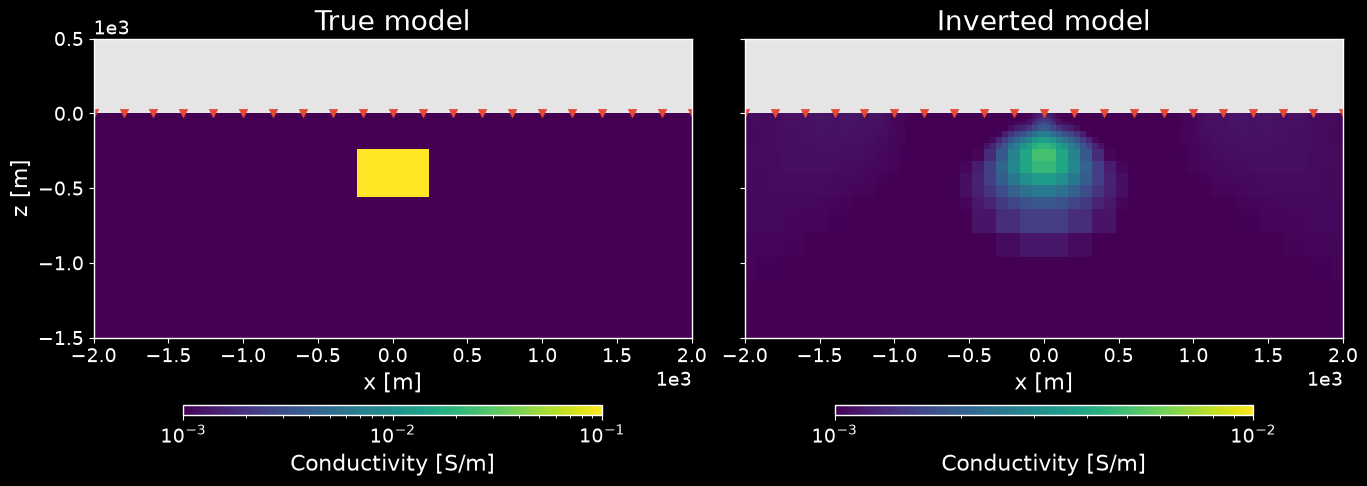

In [32]:
figs_dir = pathlib.Path("..") / "figs"

if not figs_dir.exists():
    figs_dir.mkdir()

plt.style.use("ggplot")
plt.style.use('poster.mplstyle')

figsize_cm = (35, 15)
figsize_inch = tuple(s * 0.3937008 for s in figsize_cm)

x, z = receivers_locations.T

fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True, figsize=figsize_inch)


# Colorbar kwargs
# ---------------
cbar_kwargs = dict(
    orientation="horizontal", shrink=0.7, aspect=42, pad=0.12, label="Conductivity [S/m]"
)

# True model
# ----------
norm = LogNorm(vmin=1e-3, vmax=1e-1)
true_plotting_map = simpeg.maps.InjectActiveCells(true_mesh, true_active_cells, np.nan) 
tmp, = true_mesh.plot_image(
    true_plotting_map * true_conductivity,
    ax=ax1,
    grid=False,
    pcolor_opts={"norm": norm, "cmap": "viridis", "rasterized": True},
)
plt.colorbar(tmp, ax=ax1, **cbar_kwargs)
ax1.scatter(x, z, marker="v")

# Inverted model
# --------------
values = log_plotting_map * inverted_model
norm = LogNorm(vmin=1e-3, vmax=1e-2)

tmp, = mesh.plot_image(
    values,
    ax=ax2,
    grid=False,
    pcolor_opts={"norm": norm, "cmap": "viridis", "rasterized": True},
)
plt.colorbar(tmp, ax=ax2, **cbar_kwargs)
ax2.scatter(x, z, marker="v")


ax1.set_ylabel("z [m]")
ax1.set_title("True model")
ax2.set_title("Inverted model")

for ax in (ax1, ax2):
    ax.set_xlim(-2e3, 2e3)
    ax.set_ylim(-1.5e3, 500)
    ax.set_xlabel("x [m]")
    ax.ticklabel_format(style="sci", scilimits=(0, 0))
    ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(figs_dir / "true-and-inverted-models.svg", dpi=300, bbox_inches="tight")
plt.show()